# Clustering Analysis – Identifying Optimal Clusters (Elbow Method)

Clustering analysis is used to group customers into segments based on similar characteristics.

In this project, **K-Means clustering** is used to identify natural customer segments that may reveal patterns related to customer churn.

However, before applying K-Means, it is necessary to determine the **optimal number of clusters (K)**.

To identify the best value of K, the **Elbow Method** is used.

The elbow method evaluates clustering performance by measuring the **Within-Cluster Sum of Squares (WCSS)**.

WCSS represents the total squared distance between data points and their respective cluster centroids.

Lower WCSS values indicate tighter clusters.

As the number of clusters increases:

- WCSS decreases
- but improvements gradually diminish

The optimal number of clusters is identified where the rate of improvement sharply decreases, forming an **"elbow" shape** in the graph.

#### Import Required Libraries

The following libraries are required for clustering analysis:

- pandas for data manipulation
- matplotlib for visualizations
- scikit-learn for the K-Means clustering algorithm

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

print("Libraries imported successfully.")

Libraries imported successfully.


#### Load Scaled Dataset

For clustering analysis, the **scaled training dataset** is used to ensure all features contribute equally to distance calculations.

The dataset was previously normalized using StandardScaler during the data preparation stage.

In [2]:
X_scaled = pd.read_csv(r"c:/Users/Prometheus/.vscode/Customer_Churn_Analysis/X_train_scaled.csv")

print("Dataset loaded successfully.")
print("Dataset shape:", X_scaled.shape)

print("\nFirst 5 rows of the dataset:")
print(X_scaled.head())

Dataset loaded successfully.
Dataset shape: (5392, 11)

First 5 rows of the dataset:
   SeniorCitizen    tenure  MonthlyCharges  gender_Male  Dependents_Yes  \
0      -0.450593  0.944773        1.486201    -1.013443        1.511887   
1      -0.450593  1.232687       -0.234838    -1.013443       -0.661425   
2      -0.450593  0.821382        0.946267    -1.013443       -0.661425   
3      -0.450593  1.602861        1.621184     0.986735        1.511887   
4      -0.450593 -0.988360        0.338842     0.986735       -0.661425   

   PhoneService_Yes  MultipleLines_Yes  InternetService_Fiber optic  \
0          0.338734           1.164308                     1.130056   
1          0.338734          -0.858879                    -0.884912   
2          0.338734          -0.858879                    -0.884912   
3          0.338734          -0.858879                    -0.884912   
4          0.338734          -0.858879                    -0.884912   

   Contract_One year  Contract_Two ye

#### Inspect Dataset Structure

Before performing clustering, we verify the dataset structure to confirm:

- Number of observations
- Number of features
- Feature names

In [3]:
print("\nDataset Info:\n")
print(X_scaled.info())

print("\nFeature Columns:\n")
print(X_scaled.columns)


Dataset Info:

<class 'pandas.DataFrame'>
RangeIndex: 5392 entries, 0 to 5391
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   SeniorCitizen                5392 non-null   float64
 1   tenure                       5392 non-null   float64
 2   MonthlyCharges               5392 non-null   float64
 3   gender_Male                  5392 non-null   float64
 4   Dependents_Yes               5392 non-null   float64
 5   PhoneService_Yes             5392 non-null   float64
 6   MultipleLines_Yes            5392 non-null   float64
 7   InternetService_Fiber optic  5392 non-null   float64
 8   Contract_One year            5392 non-null   float64
 9   Contract_Two year            5392 non-null   float64
 10  Churn_Yes                    5392 non-null   float64
dtypes: float64(11)
memory usage: 463.5 KB
None

Feature Columns:

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'gender_Male',


### Apply the Elbow Method

The elbow method involves running the K-Means algorithm multiple times with different values of K.

For each value of K:

1. A K-Means model is trained.
2. The Within-Cluster Sum of Squares (WCSS) is calculated.
3. WCSS values are stored for visualization.

The optimal number of clusters is determined where the **decrease in WCSS begins to slow significantly**, forming the elbow point.

In [4]:
wcss = []

print("Calculating WCSS for different cluster values...")

for i in range(1, 11):
    
    kmeans = KMeans(n_clusters=i, random_state=42)
    
    kmeans.fit(X_scaled)
    
    wcss.append(kmeans.inertia_)
    
    print(f"Clusters: {i}, WCSS: {kmeans.inertia_}")

Calculating WCSS for different cluster values...
Clusters: 1, WCSS: 59312.0
Clusters: 2, WCSS: 53512.21510848815
Clusters: 3, WCSS: 47701.63833472455
Clusters: 4, WCSS: 43489.06482342623
Clusters: 5, WCSS: 40024.56937165238
Clusters: 6, WCSS: 38237.58158804224
Clusters: 7, WCSS: 37202.11318617924
Clusters: 8, WCSS: 34366.88541418472
Clusters: 9, WCSS: 33287.864344339505
Clusters: 10, WCSS: 32396.91533706331


#### Visualizing the Elbow Curve

The WCSS values are plotted against the number of clusters.

The optimal cluster number is identified at the **elbow point**, where the reduction in WCSS begins to level off.

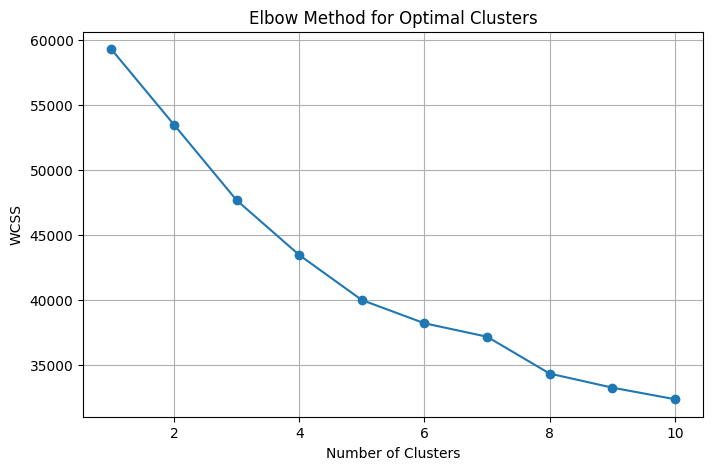

Elbow method visualization saved successfully.


In [6]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.title("Elbow Method for Optimal Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.grid(True)

plt.savefig(r"c:/Users/Prometheus/.vscode/Customer_Churn_Analysis/Clustering_Analysis/elbow_method_results.png")

plt.show()

print("Elbow method visualization saved successfully.")

#### Interpretation of the Elbow Method

The elbow plot shows how the WCSS decreases as the number of clusters increases.

Initially, adding clusters significantly reduces WCSS. However, after a certain point, the improvement becomes marginal.

The point where the curve begins to bend or flatten is considered the **optimal number of clusters**.

This point represents the best balance between:

- minimizing WCSS
- avoiding excessive cluster complexity.

# Clustering Analysis – Training the K-Means Model

After determining the optimal number of clusters using the elbow method, the next step is to train the K-Means clustering model.

K-Means is an unsupervised machine learning algorithm used to group similar observations into clusters based on feature similarity.

Each cluster is represented by a centroid, and data points are assigned to the cluster whose centroid is closest based on Euclidean distance.

In this project, the elbow method suggested an optimal cluster count of **K = 4**.

Therefore, the K-Means model will be trained using **4 clusters**.

#### Import Required Libraries

The following libraries are required:

- pandas for dataset handling
- scikit-learn for the K-Means clustering algorithm
- joblib for saving the trained model

In [7]:
import pandas as pd
from sklearn.cluster import KMeans
import joblib

print("Libraries imported successfully.")

Libraries imported successfully.


#### Load Scaled Dataset

The clustering model is trained using the scaled training dataset created during the data preparation stage.

Scaling ensures that all features contribute equally when computing distances between data points.

In [8]:
X_scaled = pd.read_csv(r"c:/Users/Prometheus/.vscode/Customer_Churn_Analysis/X_train_scaled.csv")

print("Dataset loaded successfully.")
print("Dataset shape:", X_scaled.shape)

print("\nFirst 5 rows of the dataset:")
print(X_scaled.head())

Dataset loaded successfully.
Dataset shape: (5392, 11)

First 5 rows of the dataset:
   SeniorCitizen    tenure  MonthlyCharges  gender_Male  Dependents_Yes  \
0      -0.450593  0.944773        1.486201    -1.013443        1.511887   
1      -0.450593  1.232687       -0.234838    -1.013443       -0.661425   
2      -0.450593  0.821382        0.946267    -1.013443       -0.661425   
3      -0.450593  1.602861        1.621184     0.986735        1.511887   
4      -0.450593 -0.988360        0.338842     0.986735       -0.661425   

   PhoneService_Yes  MultipleLines_Yes  InternetService_Fiber optic  \
0          0.338734           1.164308                     1.130056   
1          0.338734          -0.858879                    -0.884912   
2          0.338734          -0.858879                    -0.884912   
3          0.338734          -0.858879                    -0.884912   
4          0.338734          -0.858879                    -0.884912   

   Contract_One year  Contract_Two ye

#### Initialize the K-Means Model

The K-Means clustering algorithm is initialized with the optimal number of clusters determined using the elbow method.

Parameters used:

- **n_clusters = 4** (based on elbow method)
- **random_state = 42** (for reproducibility)
- **n_init = 10** (number of times the algorithm runs with different centroid seeds)

In [10]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

print("K-Means model initialized with 4 clusters.")

K-Means model initialized with 4 clusters.


#### Train the K-Means Model

The K-Means algorithm is trained on the scaled dataset.

During training, the algorithm performs the following steps:

1. Randomly initialize cluster centroids.
2. Assign each data point to the nearest centroid.
3. Recalculate centroids based on cluster members.
4. Repeat until cluster assignments stabilize.

The result is a set of clusters representing groups of similar customers.

In [11]:
kmeans.fit(X_scaled)

print("K-Means model trained successfully.")

K-Means model trained successfully.


#### Cluster Centers

Cluster centers represent the average feature values for each cluster.

These centroids define the characteristics of each customer segment.

In [12]:
print("Cluster Centers:\n")

centers = pd.DataFrame(
kmeans.cluster_centers_,
columns=X_scaled.columns
)

print(centers)

Cluster Centers:

   SeniorCitizen    tenure  MonthlyCharges  gender_Male  Dependents_Yes  \
0      -0.056123 -0.059626       -0.805599     0.056922       -0.038801   
1       0.258596 -0.611406        0.441107    -0.066484       -0.274304   
2      -0.076147  0.243301       -0.026683     0.010784        0.109796   
3      -0.090475  0.218731       -0.037848     0.018269        0.100952   

   PhoneService_Yes  MultipleLines_Yes  InternetService_Fiber optic  \
0         -2.952171          -0.089703                    -0.002683   
1          0.338734           0.002556                    -0.019105   
2          0.338734           1.164308                     0.438684   
3          0.338734          -0.858879                    -0.319446   

   Contract_One year  Contract_Two year  Churn_Yes  
0           0.018990           0.015795  -0.038746  
1          -0.037555          -0.018562   1.662148  
2           0.006667           0.104745  -0.583911  
3           0.013493          -0.07192

#### Assign Cluster Labels

After training the model, each customer is assigned a cluster label.

Cluster labels represent the segment to which each customer belongs.

In [13]:
clusters = kmeans.predict(X_scaled)

print("Cluster labels assigned successfully.")
print("First 20 cluster labels:\n", clusters[:20])

Cluster labels assigned successfully.
First 20 cluster labels:
 [2 3 3 3 3 3 0 3 0 2 2 3 1 1 2 1 1 1 0 3]


#### Append Cluster Labels to Dataset

The cluster labels are appended to the dataset to identify which cluster each customer belongs to.

This dataset will be used later for visualization and interpretation of customer segments.

In [14]:
X_clustered = X_scaled.copy()

X_clustered["Cluster"] = clusters

print("Cluster column added.")

print("\nCluster Distribution:")
print(X_clustered["Cluster"].value_counts())

Cluster column added.

Cluster Distribution:
Cluster
3    2024
2    1533
1    1280
0     555
Name: count, dtype: int64


#### Save Clustered Dataset

The clustered dataset is saved for further analysis and visualization.

In [15]:
X_clustered.to_csv(
r"c:/Users/Prometheus/.vscode/Customer_Churn_Analysis/Clustering_Analysis/clustered_customers.csv",
index=False
)

print("Clustered dataset saved successfully.")

Clustered dataset saved successfully.


#### Save the Trained Model

The trained K-Means model is saved so that it can be reused later without retraining.

In [16]:
joblib.dump(
kmeans,
r"c:/Users/Prometheus/.vscode/Customer_Churn_Analysis/Clustering_Analysis/kmeans_model.pkl"
)

print("K-Means model saved successfully.")

K-Means model saved successfully.


# Visualisation and Interpretation of K-Means Clusters

After training the K-Means model and assigning cluster labels, we visualize the clusters in two dimensions using **Principal Component Analysis (PCA)**.  

Visualization allows us to:

- Understand the relative positions and separation of clusters  
- Interpret each cluster in terms of customer characteristics  
- Identify patterns related to **customer churn**  

Next, we will summarize cluster profiles to provide **actionable insights** for business stakeholders.

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import seaborn as sns

print("Libraries for cluster visualization imported successfully.")

Libraries for cluster visualization imported successfully.


#### Load Clustered Dataset

The dataset includes all scaled features and a **'Cluster' column** representing assigned cluster labels (0–3).  
This dataset will be used for visualization and cluster profiling.

In [19]:
X_clustered = pd.read_csv(
    r"c:/Users/Prometheus/.vscode/Customer_Churn_Analysis/Clustering_Analysis/clustered_customers.csv"
)

print("Clustered dataset loaded successfully.")
print("Dataset shape:", X_clustered.shape)
print("\nFirst 5 rows:\n", X_clustered.head())

Clustered dataset loaded successfully.
Dataset shape: (5392, 12)

First 5 rows:
    SeniorCitizen    tenure  MonthlyCharges  gender_Male  Dependents_Yes  \
0      -0.450593  0.944773        1.486201    -1.013443        1.511887   
1      -0.450593  1.232687       -0.234838    -1.013443       -0.661425   
2      -0.450593  0.821382        0.946267    -1.013443       -0.661425   
3      -0.450593  1.602861        1.621184     0.986735        1.511887   
4      -0.450593 -0.988360        0.338842     0.986735       -0.661425   

   PhoneService_Yes  MultipleLines_Yes  InternetService_Fiber optic  \
0          0.338734           1.164308                     1.130056   
1          0.338734          -0.858879                    -0.884912   
2          0.338734          -0.858879                    -0.884912   
3          0.338734          -0.858879                    -0.884912   
4          0.338734          -0.858879                    -0.884912   

   Contract_One year  Contract_Two year  

#### Dimensionality Reduction Using PCA

Principal Component Analysis (PCA) reduces the 11-dimensional feature space to 2 dimensions.  
This allows us to visualize clusters in a 2D scatter plot while retaining most of the variance.

In [20]:
# Apply PCA to reduce features to 2 dimensions for plotting
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_clustered.drop('Cluster', axis=1))

print("PCA transformation completed.")
print("Shape after PCA:", X_pca.shape)

PCA transformation completed.
Shape after PCA: (5392, 2)


#### Cluster Visualization

The 2D scatter plot shows the separation of customer clusters in PCA space.  

- Each color represents a cluster (0–3)  
- Cluster size differences can be observed visually  
- Clear separation indicates well-defined clusters

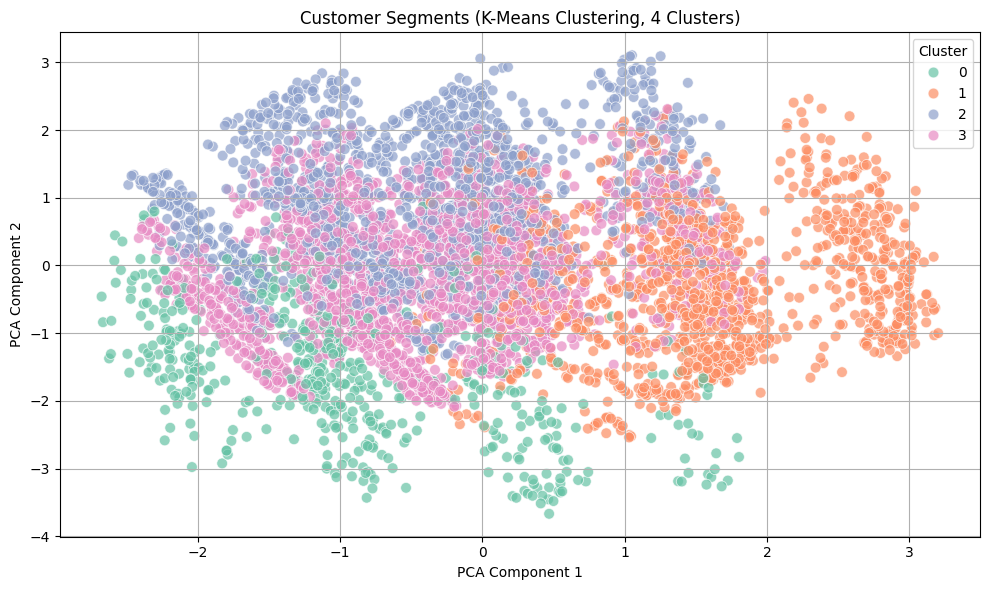

Cluster visualization saved successfully.


In [22]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    x=X_pca[:,0], y=X_pca[:,1], 
    hue=X_clustered['Cluster'], 
    palette='Set2',
    s=60, alpha=0.7
)
plt.title("Customer Segments (K-Means Clustering, 4 Clusters)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend(title='Cluster')
plt.grid(True)
plt.tight_layout()

plt.savefig(
    r"c:/Users/Prometheus/.vscode/Customer_Churn_Analysis/Clustering_Analysis/cluster_visualization.png"
)

plt.show()
print("Cluster visualization saved successfully.")

#### Cluster Profile Summary

The mean values of each feature within a cluster help describe the characteristics of each customer segment:

- **Cluster 3:** Largest group, moderate tenure, low churn proportion  
- **Cluster 2:** High tenure, higher fiber optic usage  
- **Cluster 1:** Moderate monthly charges, more dependents  
- **Cluster 0:** Smallest segment, distinct characteristics  

These summaries can be used to **label clusters** and provide **actionable insights** for churn management.

In [24]:
cluster_profile = X_clustered.groupby('Cluster').mean()
cluster_profile.to_csv(
    r"c:/Users/Prometheus/.vscode/Customer_Churn_Analysis/Clustering_Analysis/cluster_profile_summary.csv"
)

print("Cluster profiles computed and saved.")
print("\nCluster Profile Summary:\n", cluster_profile)

Cluster profiles computed and saved.

Cluster Profile Summary:
          SeniorCitizen    tenure  MonthlyCharges  gender_Male  Dependents_Yes  \
Cluster                                                                         
0            -0.056123 -0.059626       -0.805599     0.056922       -0.038801   
1             0.258596 -0.611406        0.441107    -0.066484       -0.274304   
2            -0.076147  0.243301       -0.026683     0.010784        0.109796   
3            -0.090475  0.218731       -0.037848     0.018269        0.100952   

         PhoneService_Yes  MultipleLines_Yes  InternetService_Fiber optic  \
Cluster                                                                     
0               -2.952171          -0.089703                    -0.002683   
1                0.338734           0.002556                    -0.019105   
2                0.338734           1.164308                     0.438684   
3                0.338734          -0.858879                    

#### Assigning Interpretative Cluster Labels

Cluster labels were assigned based on feature analysis to provide actionable business insight:

- High-Value Customers: Premium customers with specific churn characteristics  
- Medium-Risk Customers: Moderate churn risk, targeted retention needed  
- Long-Term Low Churn: Loyal customers with low churn probability  
- Large Volume Low-Risk Customers: Large segment, mostly low-risk

In [25]:
cluster_labels = {
    0: "High-Value Customers",
    1: "Medium-Risk Customers",
    2: "Long-Term Low Churn",
    3: "Large Volume Low-Risk Customers"
}

X_clustered['Cluster_Label'] = X_clustered['Cluster'].map(cluster_labels)
X_clustered.to_csv(
    r"c:/Users/Prometheus/.vscode/Customer_Churn_Analysis/Clustering_Analysis/clustered_customers_labeled.csv",
    index=False
)

print("Cluster labels added and saved.")

Cluster labels added and saved.
